# 02 — Regla de priorización de SKU para desabastecimiento

Segundo notebook de la cadena. Lee `panel_diario`, `ventana_activa` y
`ventana_activa_negocio` de `01_calidad_y_panel` (por los lectores de
`common_priorizacion.py` -- nunca `pd.read_csv`/`read_parquet` directo) y
no recalcula nada de eso. Implementa las 7 condiciones de la regla de
negocio, consolida al grano producto×sucursal, y contrasta contra un ABC
puro por valor.

## Regla de negocio (dada por el negocio, no derivada del EDA)

1. **Espacio en bodega**: envases líquidos ≥3000 cm³, o peso ≥3000 gramos.
2. **Perecederos**: frutas y verduras, huevos.
3. **Refrigerados**: lácteos, pollo (avícola), pescado (mariscos), carnes (cárnicos).
4. **Papel higiénico de 18 o más rollos por paquete** (ajustado con el negocio).
5. **Productos de temporada**: natilla, buñuelo, galleta navideña, vinos y licores.
6. **Top 50 más vendidos por sucursal** (sucursales reales), entre los que no calzan en 1-5.
7. **Vendidos todos los días** dentro de su ventana activa (a nivel negocio, umbral de frecuencia).

**Cadena**: `01_calidad_y_panel` → **`02_regla_priorizacion`** →
`03_calendario_estacionalidad` → `04_demanda_y_baseline` → `05_sintesis`.

In [1]:
import sys
sys.path.insert(0, '.')
from common_priorizacion import (
    PARAMS, DW, registrar_huella,
    leer_panel, leer_panel_negocio, leer_ventana, leer_ventana_negocio, verificar_huella,
)

import numpy as np
import pandas as pd
import re
import json
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (11, 4)
COLOR_PRIORITARIO = '#d1495b'
COLOR_NO_PRIORITARIO = '#66a3c4'


## 0. Carga

Tablas del DW recargadas directamente (barato, ~1,6M filas, no son un
artefacto exclusivo de 01), y los artefactos de 01 por sus lectores. Se
verifica la huella de `panel_diario.parquet` contra `huella_01.json` antes
de usarlo.

In [2]:
dim_producto = pd.read_csv(f'{DW}/dim_producto.csv', dtype={'codigo_item': str})
dim_sucursal = pd.read_csv(f'{DW}/dim_sucursal.csv')
fact_ventas = pd.read_csv(
    f'{DW}/fact_ventas.csv',
    dtype={'codigo_item': str, 'sucursal': 'category', 'codigo_proveedor': 'category'},
    parse_dates=['fecha'],
)
SUCURSALES_REALES = [s for s in dim_sucursal['nombre']
                     if s not in ('SIN_SUCURSAL', 'BODEGA_CENTRAL')]  # INV-62: BODEGA_CENTRAL no vende directo
ventas = fact_ventas.loc[(~fact_ventas['es_devolucion']) & (fact_ventas['cantidad'] > 0)].copy()

verificar_huella('huella_01.json', [
    'panel_diario.parquet', 'panel_diario_negocio.parquet',
    'ventana_activa.parquet', 'ventana_activa_negocio.parquet',
])

diario = leer_panel()
diario_negocio = leer_panel_negocio()
ventana = leer_ventana()
ventana_negocio = leer_ventana_negocio()

# Catálogo activo = misma definición de "al menos 1 venta" que ya calculó 01
# en ventana_negocio -- no se recalcula desde fact_ventas.
catalogo_activo = dim_producto['codigo_item'].isin(set(ventana_negocio['codigo_item']))
assert catalogo_activo.sum() == len(ventana_negocio)
print('diario:', diario.shape, '| ventana:', ventana.shape, '| ventana_negocio:', ventana_negocio.shape)


Huella verificada OK contra huella_01.json.


diario: (1417186, 5) | ventana: (10805, 8) | ventana_negocio: (4377, 7)


## 1. Condición 1 — tamaño/peso de presentación

Parseo en dos capas: **directa** (unidad explícita en el nombre) e
**inferida** (número suelto sin unidad, con reglas de categoría/palabra
clave para decidir si es volumen o peso -- ver `PARAMS['UMBRAL_NUMERO_SUELTO_INFERENCIA']`).

El umbral de 3000 aplica igual a `volumen_cm3` y a `peso_g` -- la regla de
negocio dice "líquidos ≥3000 cm³ **o** peso ≥3000 g", así que un producto
sólido de 3000 g cuenta igual que un líquido de 3000 cm³. La distinción
líquido/sólido solo importa para decidir en qué unidad se interpreta un
número suelto durante la inferencia.

In [3]:
CORE_UNIDAD = {
    'kg': r'K\.?G\.?S?\b|KILO',
    'g':  r'G\.?R?\.?S?\b(?!\w)',
    'l':  r'L\.?T\.?S?\b|LITRO',
    'ml': r'M\.?L\.?S?\b',
    'cm3': r'C\.?M\.?3?\b|CC\b',
}
PATRONES_UNIDAD = [
    (u, re.compile(r'(\d+(?:[.,]\d+)?)(?:\s*-\s*(\d+(?:[.,]\d+)?))?\s*(?<![A-Za-z])(?:' + core + ')', re.IGNORECASE))
    for u, core in CORE_UNIDAD.items()
]

LIQUID_KEYWORDS = re.compile(
    r'LIQUID|\bDET\b|\bBLQ\b|LIMPI|DESENGRASANTE|DESINFECTANTE|SUAVIZANTE|SUAVITEL|'
    r'\bCLORO\b|VARSOL|SHAMPOO|CHAMPU|CHAMP |ACEITE|VINAGRE|JARABE|\bAGUA\b|JUGO|'
    r'GASEOSA|ALCOHOL|ENJUAGUE|LOCION|COLONIA|CERVEZA|\bVINO\b|WHISKY|AGUARDIENTE|\bRON\b|MALTA',
    re.IGNORECASE,
)
CATEGORIAS_LIQUIDAS = {'Bebidas', 'Licores', 'Aceites y sustitutos'}
LACTEO_LIQUIDO = re.compile(r'LECHE|KUMIS|YOGUR', re.IGNORECASE)
LACTEO_NO_LIQUIDO = re.compile(r'CONDENSADA|POLVO', re.IGNORECASE)
NUMERO_SUELTO = re.compile(r'\*\s*(\d+)(?:\s*(UND|UN|ROLLOS?))?\b', re.IGNORECASE)

def es_liquido(nombre, categoria):
    if categoria in CATEGORIAS_LIQUIDAS:
        return True
    if categoria == 'Lácteos' and LACTEO_LIQUIDO.search(nombre) and not LACTEO_NO_LIQUIDO.search(nombre):
        return True
    return bool(LIQUID_KEYWORDS.search(nombre))

def extraer_tamano(nombre, categoria):
    nombre = str(nombre)
    vol_cm3, peso_g = None, None
    for unidad, patron in PATRONES_UNIDAD:
        for m in patron.finditer(nombre):
            v1 = float(m.group(1).replace(',', '.'))
            v2 = float(m.group(2).replace(',', '.')) if m.group(2) else None
            val = max(v1, v2) if v2 else v1
            if unidad == 'kg':
                peso_g = val * 1000 if peso_g is None else max(peso_g, val * 1000)
            elif unidad == 'g':
                peso_g = val if peso_g is None else max(peso_g, val)
            elif unidad == 'l':
                vol_cm3 = val * 1000 if vol_cm3 is None else max(vol_cm3, val * 1000)
            else:
                vol_cm3 = val if vol_cm3 is None else max(vol_cm3, val)

    inferido = False
    if vol_cm3 is None and peso_g is None:
        m = NUMERO_SUELTO.search(nombre)
        if m and m.group(2) is None and float(m.group(1)) >= PARAMS['UMBRAL_NUMERO_SUELTO_INFERENCIA']:
            inferido = True
            val = float(m.group(1))
            if es_liquido(nombre, categoria):
                vol_cm3 = val
            else:
                peso_g = val
    return pd.Series({'volumen_cm3': vol_cm3, 'peso_g': peso_g, 'tamano_inferido': inferido})

dim_producto[['volumen_cm3', 'peso_g', 'tamano_inferido']] = dim_producto.apply(
    lambda r: extraer_tamano(r['nombre'], r['categoria']), axis=1
)
tiene_tamano = dim_producto[['volumen_cm3', 'peso_g']].notna().any(axis=1)
es_inferido = dim_producto['tamano_inferido']
print(f'cobertura directa: {(tiene_tamano & ~es_inferido).mean():.1%}')
print(f'cobertura inferida adicional: {es_inferido.mean():.1%}')
print(f'cobertura total: {tiene_tamano.mean():.1%}')


cobertura directa: 55.8%
cobertura inferida adicional: 13.9%
cobertura total: 69.8%


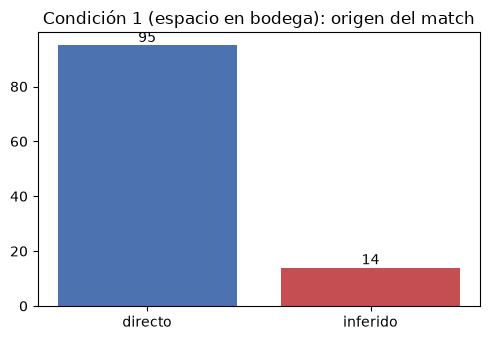

109 productos cumplen condición 1 en total


In [4]:
dim_producto['cond1_espacio_bodega'] = (
    (dim_producto['volumen_cm3'] >= PARAMS['UMBRAL_VOLUMEN_CM3']) | (dim_producto['peso_g'] >= PARAMS['UMBRAL_PESO_G'])
)
n_directo = (dim_producto['cond1_espacio_bodega'] & ~dim_producto['tamano_inferido']).sum()
n_inferido = (dim_producto['cond1_espacio_bodega'] & dim_producto['tamano_inferido']).sum()

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['directo', 'inferido'], [n_directo, n_inferido], color=['#4c72b0', '#c44e52'])
ax.set_title('Condición 1 (espacio en bodega): origen del match')
for i, v in enumerate([n_directo, n_inferido]):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()
print(dim_producto['cond1_espacio_bodega'].sum(), 'productos cumplen condición 1 en total')


1335 productos sin tamaño parseado representan 33.2% del valor histórico total


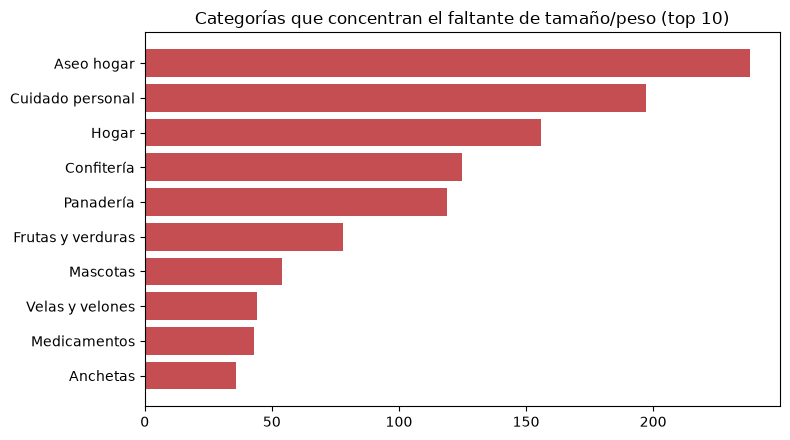

categorías que más concentran el faltante: {'Aseo hogar': np.int64(238), 'Cuidado personal': np.int64(197), 'Hogar': np.int64(156)}


In [5]:
# Cuantificar el VALOR en riesgo por no tener tamaño parseado -- no basta
# con contar nombres, importa cuánto ingreso representan.
sin_tamano = dim_producto.loc[~tiene_tamano, 'codigo_item']
valor_por_producto_todo = ventas.groupby('codigo_item', observed=True)['valor_total'].sum()
valor_sin_tamano = valor_por_producto_todo.reindex(sin_tamano).sum()
valor_total_todo = valor_por_producto_todo.sum()
print(f'{len(sin_tamano)} productos sin tamaño parseado representan {valor_sin_tamano/valor_total_todo:.1%} del valor histórico total')

categorias_sin_tamano = dim_producto.loc[~tiene_tamano, 'categoria'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(categorias_sin_tamano.index[::-1], categorias_sin_tamano.values[::-1], color='#c44e52')
ax.set_title('Categorías que concentran el faltante de tamaño/peso (top 10)')
plt.tight_layout()
plt.show()
top3_sin_tamano = categorias_sin_tamano.head(3)
print('categorías que más concentran el faltante:', dict(top3_sin_tamano))


El faltante se concentra en categorías como Aseo hogar y Hogar, que sí
tienen productos voluminosos (baldes, escobas, cobijas) sin unidad
explícita en el nombre -- ahí el riesgo de subestimar la condición 1 es
real, no un ruido disperso por todo el catálogo. Son las categorías a
priorizar si más adelante se hace una revisión manual del parseo.

## 2. Condiciones 2 y 3 — perecederos y refrigerados

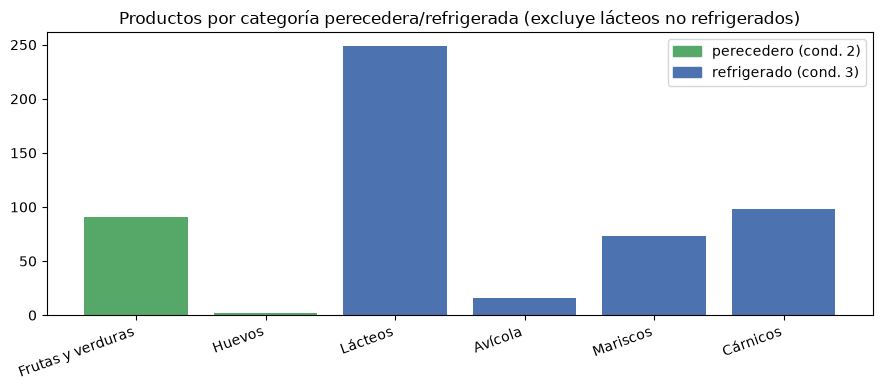

condición 2 (perecederos): 93
condición 3 (refrigerados): 426 (excluidos 10 lácteos no refrigerados: condensada/en polvo)


In [6]:
CATEGORIAS_PERECEDERAS_ESTRICTO = ['Frutas y verduras', 'Huevos']
CATEGORIAS_REFRIGERADAS = ['Lácteos', 'Avícola', 'Mariscos', 'Cárnicos']

es_lacteo_no_refrigerado = (
    dim_producto['categoria'].eq('Lácteos')
    & dim_producto['nombre'].str.contains('CONDENSADA|EN POLVO|POLVO', case=False, regex=True, na=False)
)
dim_producto['cond2_perecedero'] = dim_producto['categoria'].isin(CATEGORIAS_PERECEDERAS_ESTRICTO)
dim_producto['cond3_refrigerado'] = (
    dim_producto['categoria'].isin(CATEGORIAS_REFRIGERADAS) & ~es_lacteo_no_refrigerado
)

conteo_2_3 = pd.DataFrame({
    'categoria': CATEGORIAS_PERECEDERAS_ESTRICTO + CATEGORIAS_REFRIGERADAS,
    'grupo': ['perecedero'] * len(CATEGORIAS_PERECEDERAS_ESTRICTO) + ['refrigerado'] * len(CATEGORIAS_REFRIGERADAS),
})
conteo_2_3['n_productos'] = conteo_2_3['categoria'].map(dim_producto['categoria'].value_counts())

fig, ax = plt.subplots(figsize=(9, 4))
colores = conteo_2_3['grupo'].map({'perecedero': '#55a868', 'refrigerado': '#4c72b0'})
ax.bar(conteo_2_3['categoria'], conteo_2_3['n_productos'], color=colores)
ax.set_title('Productos por categoría perecedera/refrigerada (excluye lácteos no refrigerados)')
plt.xticks(rotation=20, ha='right')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ['#55a868', '#4c72b0']]
ax.legend(handles, ['perecedero (cond. 2)', 'refrigerado (cond. 3)'])
plt.tight_layout()
plt.show()

print('condición 2 (perecederos):', dim_producto['cond2_perecedero'].sum())
print('condición 3 (refrigerados):', dim_producto['cond3_refrigerado'].sum(),
      f'(excluidos {es_lacteo_no_refrigerado.sum()} lácteos no refrigerados: condensada/en polvo)')


## 3. Condición 4 — papel higiénico ≥18 rollos

Revisados los 54 nombres reales de papel higiénico: **todos** usan
notación `*N` (con o sin "UND"/"ROLLOS"), no hay formatos alternativos sin
asterisco en los datos -- el parseo no está perdiendo casos.

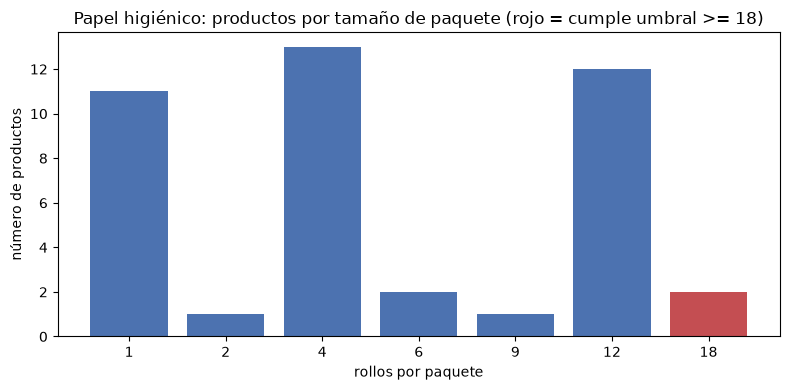

42 productos de papel higiénico, máximo de rollos observado: 18
condición 4: 2 productos


In [7]:
es_papel_higienico = (
    dim_producto['categoria'].eq('Aseo hogar')
    & dim_producto['nombre'].str.contains('PAPEL HIG', case=False, na=False)
)
PATRON_MULTIPLICADOR = re.compile(r'\*\s*(\d+)\s*(?:UND|UN|ROLLOS?)?\b', re.IGNORECASE)

def extraer_rollos(nombre):
    m = PATRON_MULTIPLICADOR.search(str(nombre))
    return int(m.group(1)) if m else 1

dim_producto['rollos_paquete'] = np.nan
dim_producto.loc[es_papel_higienico, 'rollos_paquete'] = dim_producto.loc[es_papel_higienico, 'nombre'].apply(extraer_rollos)
dim_producto['cond4_papel_higienico'] = es_papel_higienico & (dim_producto['rollos_paquete'] >= PARAMS['UMBRAL_ROLLOS_PAPEL_HIGIENICO'])

conteo_rollos = dim_producto.loc[es_papel_higienico, 'rollos_paquete'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
umbral_rollos = PARAMS['UMBRAL_ROLLOS_PAPEL_HIGIENICO']
colores = ['#c44e52' if r >= umbral_rollos else '#4c72b0' for r in conteo_rollos.index]
ax.bar(conteo_rollos.index.astype(int).astype(str), conteo_rollos.values, color=colores)
ax.set_title(f'Papel higiénico: productos por tamaño de paquete (rojo = cumple umbral >= {umbral_rollos})')
ax.set_xlabel('rollos por paquete')
ax.set_ylabel('número de productos')
plt.tight_layout()
plt.show()

max_rollos = int(dim_producto.loc[es_papel_higienico, 'rollos_paquete'].max())
print(f'{es_papel_higienico.sum()} productos de papel higiénico, máximo de rollos observado: {max_rollos}')
print('condición 4:', dim_producto['cond4_papel_higienico'].sum(), 'productos')


La condición es marginal en volumen (2 de 54 productos de papel
higiénico) y se conserva por trazabilidad con el requerimiento del negocio,
no por su impacto en el catálogo -- revisar los 54 nombres uno por uno
confirmó que no hay ningún patrón de empaque sin capturar por el parseo.

## 4. Condición 5 — productos de temporada

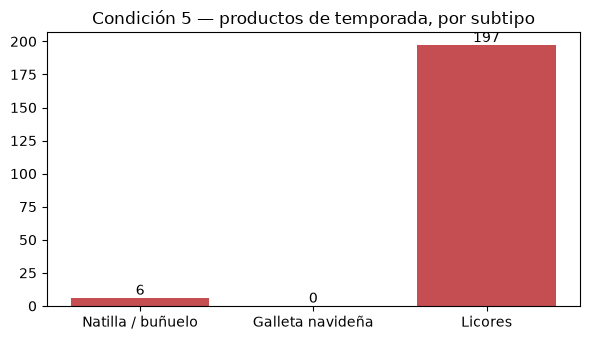

condición 5, total únicos: 203


In [8]:
es_temporada_navidena = dim_producto['nombre'].str.contains('NATILLA|BU[ÑN]UELO', case=False, regex=True, na=False)
es_galleta_navidena = (
    dim_producto['nombre'].str.contains('GALLETA', case=False, na=False)
    & dim_producto['nombre'].str.contains('NAVID', case=False, na=False)
)
es_licor = dim_producto['categoria'].eq('Licores')
dim_producto['cond5_temporada'] = es_temporada_navidena | es_galleta_navidena | es_licor

conteo_temporada = pd.Series({
    'Natilla / buñuelo': es_temporada_navidena.sum(),
    'Galleta navideña': es_galleta_navidena.sum(),
    'Licores': es_licor.sum(),
})
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(conteo_temporada.index, conteo_temporada.values, color='#c44e52')
ax.set_title('Condición 5 — productos de temporada, por subtipo')
for i, v in enumerate(conteo_temporada.values):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()
print('condición 5, total únicos:', dim_producto['cond5_temporada'].sum())


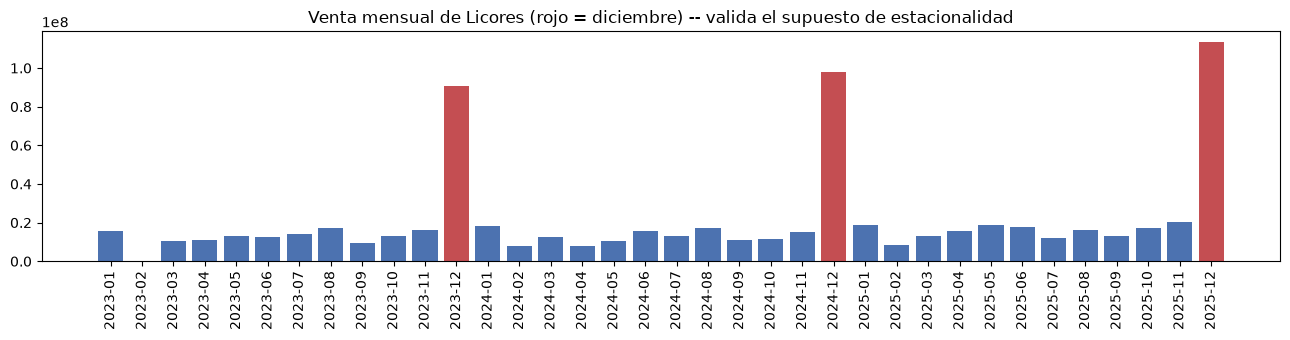

diciembre vende 7.5x el promedio de los demás meses ($302M vs $41M)


In [9]:
codigos_licor = set(dim_producto.loc[es_licor, 'codigo_item'])
venta_licor_mensual = (
    ventas.loc[ventas['codigo_item'].isin(codigos_licor)]
    .assign(mes=lambda d: d['fecha'].dt.to_period('M'))
    .groupby('mes')['valor_total'].sum()
)
fig, ax = plt.subplots(figsize=(13, 3.5))
colores = ['#c44e52' if m.month == 12 else '#4c72b0' for m in venta_licor_mensual.index]
ax.bar(venta_licor_mensual.index.astype(str), venta_licor_mensual.values, color=colores)
ax.set_title('Venta mensual de Licores (rojo = diciembre) -- valida el supuesto de estacionalidad')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

venta_licor_por_mes_num = ventas.loc[ventas['codigo_item'].isin(codigos_licor)].assign(
    mes=lambda d: d['fecha'].dt.month
).groupby('mes')['valor_total'].sum()
razon_diciembre = venta_licor_por_mes_num[12] / venta_licor_por_mes_num.drop(12).mean()
print(f'diciembre vende {razon_diciembre:.1f}x el promedio de los demás meses',
      f'(${venta_licor_por_mes_num[12]/1e6:.0f}M vs ${venta_licor_por_mes_num.drop(12).mean()/1e6:.0f}M)')


La estacionalidad de Licores es real y fuerte, no un supuesto -- queda
validada con el propio dato de venta, no solo con el criterio de categoría.
La condición 5 agrupa productos de temporada por *categoría o palabra
clave*; qué tan bien ese criterio identifica a los productos individuales
que sí tienen ese patrón (falsos positivos y negativos por SKU) se mide más
adelante en la cadena, con el detalle de calendario que este notebook
todavía no tiene.

## 5. Condiciones 6 y 7 — top 50 por sucursal y vendidos todos los días

**Condición 6**: el ranking se calcula **solo sobre sucursales reales**
(`PRINCIPAL`, `LA 21`, `GLORIETA`) -- `SIN_SUCURSAL` (facturación
electrónica sin punto de venta física) no es un cuarto punto de venta a
abastecer.

**Condición 7**: umbral explícito de frecuencia (`PARAMS['UMBRAL_FRECUENCIA_COND7']
= 0.98`) en vez de un "top 50" fijo -- con datos reales, un corte por
cantidad cae en medio de un empate de productos con frecuencia exacta 1.0.
Usa `ventana_activa_negocio` de 01 (ya calculada a nivel producto,
incluyendo `SIN_SUCURSAL`), no la recalcula.

**Asimetría intencional entre 6 y 7**: la condición 7 exige
`dias_habiles_ventana >= PARAMS['MIN_DIAS_VENTANA']` (180 días de historia
mínima); la condición 6 no exige ninguna ventana mínima. No es un filtro
olvidado -- son dos lentes distintas sobre "rotación". La condición 6 mide
**volumen absoluto** (un producto nuevo que ya vende mucho es relevante
para reposición desde ya; exigirle historia lo penalizaría sin motivo). La
condición 7 mide **regularidad** dentro de una ventana representativa
(afirmar "vendido todos los días" sin suficiente historia no significa
nada).

In [10]:
ventas_por_producto_sucursal = (
    diario.groupby(['codigo_item', 'sucursal'], observed=True)['unidades'].sum().reset_index()
)
cond_1_a_5 = dim_producto.set_index('codigo_item')[
    ['cond1_espacio_bodega', 'cond2_perecedero', 'cond3_refrigerado', 'cond4_papel_higienico', 'cond5_temporada']
].any(axis=1)
ventas_por_producto_sucursal['ya_cubierto_1_5'] = ventas_por_producto_sucursal['codigo_item'].map(cond_1_a_5).fillna(False)

restante = ventas_por_producto_sucursal.loc[~ventas_por_producto_sucursal['ya_cubierto_1_5']].copy()
restante['rank_sucursal'] = restante.groupby('sucursal', observed=True)['unidades'].rank(method='first', ascending=False)
top50_por_sucursal = restante.loc[restante['rank_sucursal'] <= PARAMS['TOP_N_SUCURSAL']]

print('pares producto x sucursal en top 50 (condición 6, solo sucursales reales):', len(top50_por_sucursal))
print('esperado: 50 x', len(SUCURSALES_REALES), '=', 50 * len(SUCURSALES_REALES))
assert len(top50_por_sucursal) == PARAMS['TOP_N_SUCURSAL'] * len(SUCURSALES_REALES), 'el ranking no está limpio de SIN_SUCURSAL'
top50_por_sucursal.groupby('sucursal', observed=True).size()


pares producto x sucursal en top 50 (condición 6, solo sucursales reales): 150
esperado: 50 x 3 = 150


sucursal
GLORIETA     50
LA 21        50
PRINCIPAL    50
dtype: int64

In [11]:
# El ranking suma unidades de 2023-01 a 2025-12 completo -- ¿puede un
# producto descontinuado dominar el top-50 por volumen histórico
# acumulado, aunque ya no se venda? Diagnóstico antes de cambiar nada.
top50_con_fecha = top50_por_sucursal.merge(
    ventana[['codigo_item', 'sucursal', 'ultima_venta', 'dias_habiles_ventana']],
    on=['codigo_item', 'sucursal'], how='left'
)
maxfecha = ventana['ultima_venta'].max()
n_viejos = (top50_con_fecha['ultima_venta'] < maxfecha - pd.Timedelta(days=90)).sum()
print(top50_con_fecha['ultima_venta'].describe())
print(f'\npares del top-50 sin venta en los últimos 90 días (de {maxfecha.date()}): {n_viejos} de {len(top50_con_fecha)}')


count                    150
mean     2025-12-30 07:50:24
min      2025-12-06 00:00:00
25%      2025-12-31 00:00:00
50%      2025-12-31 00:00:00
75%      2025-12-31 00:00:00
max      2025-12-31 00:00:00
Name: ultima_venta, dtype: object

pares del top-50 sin venta en los últimos 90 días (de 2025-12-31): 0 de 150


El riesgo teórico no se materializa en estos datos: para llegar al
top-50 por unidades acumuladas, en la práctica un producto tiene que
seguir vendiéndose fuerte hasta el final del histórico (ningún par del
top-50 lleva más de 90 días sin venta). No hace falta rankear sobre una
ventana reciente ni normalizar por historia -- queda cerrado con evidencia,
no por supuesto.

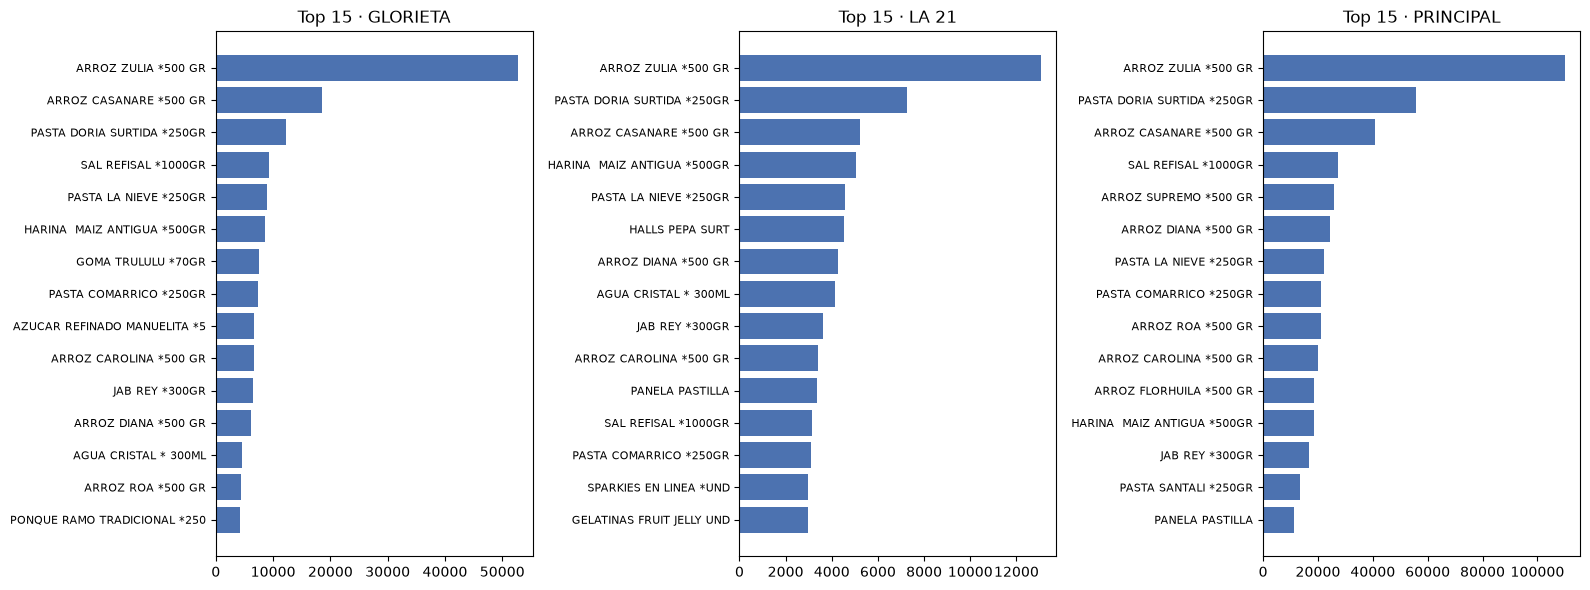

In [12]:
nombres = dim_producto.set_index('codigo_item')['nombre']
fig, axes = plt.subplots(1, len(SUCURSALES_REALES), figsize=(16, 6))
for ax, (sucursal, grupo) in zip(axes, top50_por_sucursal.groupby('sucursal', observed=True)):
    top15 = grupo.nsmallest(15, 'rank_sucursal').sort_values('unidades')
    etiquetas = top15['codigo_item'].map(nombres).str.slice(0, 28)
    ax.barh(etiquetas, top15['unidades'], color='#4c72b0')
    ax.set_title(f'Top 15 · {sucursal}')
    ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()


productos con frecuencia >= 1.0: 8
productos con frecuencia >= 0.98: 71
productos con frecuencia >= 0.95: 101


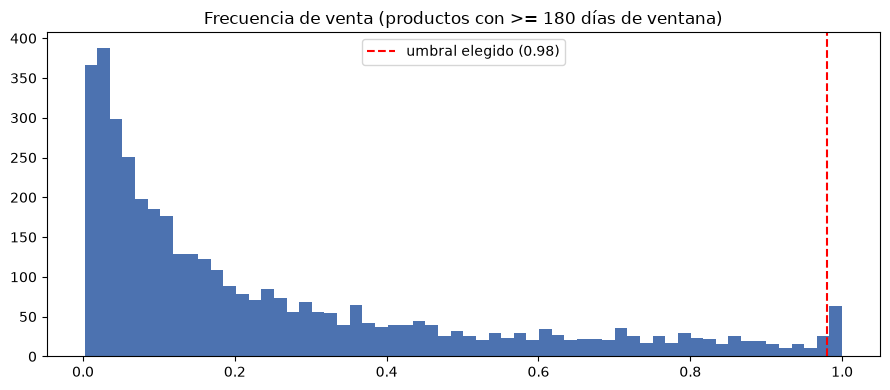

In [13]:
candidatos_cond7 = ventana_negocio.loc[ventana_negocio['dias_habiles_ventana'] >= PARAMS['MIN_DIAS_VENTANA']]
for umbral in (1.0, 0.98, 0.95):
    n = (candidatos_cond7['frecuencia_venta'] >= umbral).sum()
    print(f'productos con frecuencia >= {umbral}: {n}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(candidatos_cond7['frecuencia_venta'], bins=60, color='#4c72b0')
ax.axvline(PARAMS['UMBRAL_FRECUENCIA_COND7'], color='red', linestyle='--',
           label=f"umbral elegido ({PARAMS['UMBRAL_FRECUENCIA_COND7']})")
ax.set_title(f"Frecuencia de venta (productos con >= {PARAMS['MIN_DIAS_VENTANA']} días de ventana)")
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
dim_producto['cond7_vendido_todos_los_dias'] = dim_producto['codigo_item'].isin(
    set(candidatos_cond7.loc[candidatos_cond7['frecuencia_venta'] >= PARAMS['UMBRAL_FRECUENCIA_COND7'], 'codigo_item'])
)
print('condición 7 (umbral >=', PARAMS['UMBRAL_FRECUENCIA_COND7'], '):', dim_producto['cond7_vendido_todos_los_dias'].sum(), 'productos')


condición 7 (umbral >= 0.98 ): 71 productos


El requerimiento original de negocio decía "50 productos"; con un
umbral de frecuencia explícito el resultado no cae exactamente en 50 por
construcción. Si el negocio insiste en un cupo exacto, se puede tomar este
mismo ranking y aplicar un desempate determinista (por unidades totales,
luego por código) documentado explícitamente -- preferible a forzar el
número recortando el umbral a ojo.

In [15]:
# La condición 7 se evalúa a nivel de negocio y se propaga igual a las 3
# sucursales -- la misma asimetría de la condición 6 (vendido a diario en
# el negocio no es lo mismo que vendido a diario en cada sucursal). Se
# contrasta la decisión con la frecuencia real por sucursal.
codigos_cond7 = dim_producto.loc[dim_producto['cond7_vendido_todos_los_dias'], 'codigo_item']
frecuencia_cond7_por_sucursal = ventana.loc[ventana['codigo_item'].isin(codigos_cond7)]
tabla_cond7_sucursal = frecuencia_cond7_por_sucursal.pivot_table(index='codigo_item', columns='sucursal', values='frecuencia_venta')
n_cond7 = len(tabla_cond7_sucursal)
print(f'Frecuencia de venta POR SUCURSAL de los {n_cond7} productos marcados cond7 (a nivel negocio):')
print(tabla_cond7_sucursal.describe().loc[['min', '25%', '50%', '75%', 'max']].round(2))
n_dispar = (tabla_cond7_sucursal.max(axis=1) - tabla_cond7_sucursal.min(axis=1) > 0.2).sum()
print(f'\n{n_dispar} de {n_cond7} productos tienen una diferencia > 0.2 en frecuencia entre su mejor y peor sucursal.')


Frecuencia de venta POR SUCURSAL de los 71 productos marcados cond7 (a nivel negocio):
sucursal  GLORIETA  LA 21  PRINCIPAL
min           0.45   0.31       0.43
25%           0.73   0.59       0.86
50%           0.82   0.74       0.95
75%           0.95   0.92       0.98
max           1.00   1.00       1.00

41 de 71 productos tienen una diferencia > 0.2 en frecuencia entre su mejor y peor sucursal.


Se mantiene la condición 7 a nivel de negocio -- es una señal de
demanda del producto, no de reposición de una sucursal específica. La
dispersión por sucursal medida arriba importa para la síntesis final: si
es alta, "vendido a diario" a nivel negocio no implica que las 3
sucursales necesiten el mismo nivel de alerta.

### Pares producto×sucursal ausentes del panel

`prioridad_par` (sección 6) se construye solo con pares que tienen al
menos una venta observada. El cartesiano "catálogo activo × 3 sucursales
reales" es más grande -- los pares que faltan **nunca pueden recibir una
alerta**, por construcción. Antes de consolidar, cuánto es eso y qué tan
grave.

In [16]:
cartesiano = pd.MultiIndex.from_product([sorted(set(ventana_negocio['codigo_item'])), SUCURSALES_REALES], names=['codigo_item', 'sucursal'])
observados = pd.MultiIndex.from_frame(ventana[['codigo_item', 'sucursal']])
ausentes = cartesiano.difference(observados).to_frame(index=False)
ausentes['cumple_1_a_5'] = ausentes['codigo_item'].map(cond_1_a_5).fillna(False)

n_ausentes = len(ausentes)
n_ausentes_relevantes = int(ausentes['cumple_1_a_5'].sum())
print(f'{n_ausentes} pares producto x sucursal ausentes del panel (de {len(cartesiano)} posibles) --',
      f'{n_ausentes/len(cartesiano):.1%} del cartesiano.')
print(f'{n_ausentes_relevantes} de esos ({n_ausentes_relevantes/n_ausentes:.1%}) son de productos que cumplen alguna condición 1-5.')


2326 pares producto x sucursal ausentes del panel (de 13131 posibles) -- 17.7% del cartesiano.
417 de esos (17.9%) son de productos que cumplen alguna condición 1-5.


**Limitación de alcance declarada**: el sistema solo puede alertar
sobre pares con historia de venta en esa sucursal -- un producto que nunca
se vendió ahí (porque nunca hubo stock, o porque esa sucursal no lo
maneja) queda fuera del universo de priorización por diseño, no por
descarte activo. Distinguir "nunca tuvo stock" de "esa sucursal no lo
maneja" requeriría un maestro de surtido por sucursal que no existe en el
dato de origen.

## 6. Consolidación — a grano producto (resumen) y producto×sucursal

El grano real de un pronóstico de desabastecimiento es producto×sucursal,
no producto: un producto top-50 solo en `PRINCIPAL` no debe quedar
marcado prioritario también en `LA 21`. Se materializa la priorización al
grano correcto y se exporta aparte; la vista por producto es solo para
lectura ejecutiva.

In [17]:
condiciones = ['cond1_espacio_bodega', 'cond2_perecedero', 'cond3_refrigerado',
               'cond4_papel_higienico', 'cond5_temporada', 'cond7_vendido_todos_los_dias']
etiquetas_condiciones = ['1. Espacio bodega', '2. Perecedero', '3. Refrigerado',
                          '4. Papel hig. >=18', '5. Temporada', '7. Vendido a diario']

# Panel producto x sucursal (solo sucursales reales, solo pares con venta observada).
prioridad_par = ventana[['codigo_item', 'sucursal']].drop_duplicates().copy()
for c in condiciones:
    prioridad_par[c] = prioridad_par['codigo_item'].map(dim_producto.set_index('codigo_item')[c]).fillna(False)

pares_cond6 = set(zip(top50_por_sucursal['codigo_item'], top50_por_sucursal['sucursal']))
prioridad_par['cond6_top50_sucursal'] = list(zip(prioridad_par['codigo_item'], prioridad_par['sucursal']))
prioridad_par['cond6_top50_sucursal'] = prioridad_par['cond6_top50_sucursal'].isin(pares_cond6)

todas_condiciones_par = condiciones + ['cond6_top50_sucursal']
prioridad_par['es_prioritario'] = prioridad_par[todas_condiciones_par].any(axis=1)

print('pares producto x sucursal:', len(prioridad_par))
print('pares prioritarios:', prioridad_par['es_prioritario'].sum(),
      f"({prioridad_par['es_prioritario'].mean():.1%})")

assert not (prioridad_par['sucursal'] == 'SIN_SUCURSAL').any(), 'SIN_SUCURSAL no debe aparecer en el panel de pronóstico'
assert set(zip(prioridad_par['codigo_item'], prioridad_par['sucursal'])) <= set(zip(ventana['codigo_item'], ventana['sucursal']))

# Invariante recíproca: un producto que cumple una condición de NIVEL
# PRODUCTO (1-5, 7) debe tener TODOS sus pares marcados prioritarios -- la
# única condición que legítimamente varía por sucursal es la 6.
cond_producto_1_a_5_y_7 = dim_producto.set_index('codigo_item')[condiciones].any(axis=1)
por_producto_nunique = prioridad_par.groupby('codigo_item')['es_prioritario'].nunique()
sospechosos = por_producto_nunique.loc[por_producto_nunique > 1].index
assert not cond_producto_1_a_5_y_7.reindex(sospechosos).fillna(False).any(), \
    'un producto prioritario por condición de nivel producto (1-5,7) tiene algún par sin marcar'
print('Invariante recíproca verificada OK.')

# Parquet, no CSV -- preserva codigo_item como texto (mismo motivo que 01);
# el resto de la cadena lee esto con leer_priorizacion().
prioridad_par.to_parquet(f'{DW}/priorizacion_producto_sucursal.parquet', index=False)
print('guardado:', f'{DW}/priorizacion_producto_sucursal.parquet')


pares producto x sucursal: 10805
pares prioritarios: 2270 (21.0%)
Invariante recíproca verificada OK.
guardado: /home/ddelgadillo@redcorporativa.corpoica.org.co/otros/etl/InventaIO/data/processed_real/priorizacion_producto_sucursal.parquet


### Resumen por condición, al grano producto×sucursal

El resumen a nivel producto de más abajo es útil para lectura ejecutiva,
pero el grano real de la decisión es producto×sucursal -- la tabla
equivalente sobre `prioridad_par` es la que de verdad describe el tamaño
de cada condición.

In [18]:
filas_resumen_par = []
for c, etiqueta in zip(todas_condiciones_par, etiquetas_condiciones + ['6. Top 50 sucursal']):
    n_pares_c = int(prioridad_par[c].sum())
    codigos_c = set(prioridad_par.loc[prioridad_par[c], 'codigo_item'])
    filas_resumen_par.append({
        'condición': etiqueta,
        'n_pares': n_pares_c,
        '%_pares': n_pares_c / len(prioridad_par) * 100,
        '%_valor': valor_por_producto_todo.reindex(codigos_c).sum() / valor_por_producto_todo.sum() * 100,
    })
resumen_tabla_par = pd.DataFrame(filas_resumen_par).round(1)
resumen_tabla_par


,condición,n_pares,%_pares,%_valor
0,1. Espacio bodega,256,2.40,5.30
1,2. Perecedero,265,2.50,9.70
2,3. Refrigerado,1092,10.10,10.80
3,4. Papel hig. >=18,4,0.00,0.00
4,5. Temporada,461,4.30,4.60
5,7. Vendido a diario,213,2.00,24.80
6,6. Top 50 sucursal,150,1.40,20.20


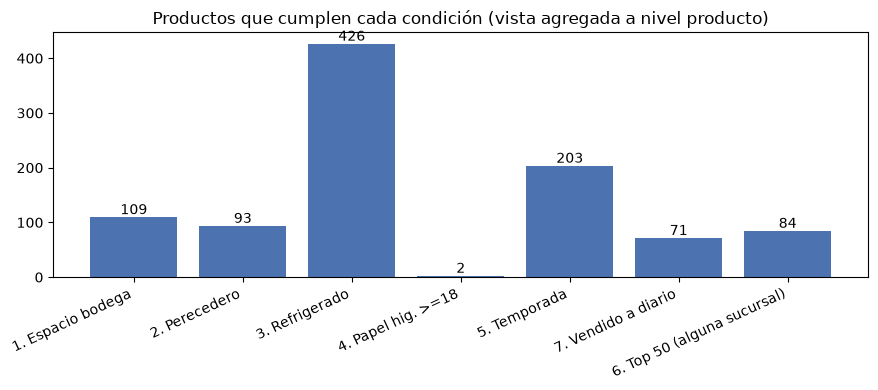

In [19]:
# Vista agregada a nivel producto (para lectura ejecutiva) -- un producto es
# prioritario si lo es en AL MENOS una sucursal real.
dim_producto['cond6_top50_alguna_sucursal'] = dim_producto['codigo_item'].isin(set(prioridad_par.loc[prioridad_par['cond6_top50_sucursal'], 'codigo_item']))
todas_condiciones_prod = condiciones + ['cond6_top50_alguna_sucursal']
dim_producto['es_prioritario'] = dim_producto[todas_condiciones_prod].any(axis=1)

resumen = dim_producto[todas_condiciones_prod].sum()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(etiquetas_condiciones + ['6. Top 50 (alguna sucursal)'], resumen.values, color='#4c72b0')
ax.set_title('Productos que cumplen cada condición (vista agregada a nivel producto)')
plt.xticks(rotation=25, ha='right')
for i, v in enumerate(resumen.values):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()


In [20]:
# Tabla resumen ampliada con %_valor por condición, y denominador sobre
# catálogo activo además del total. Reusa valor_por_producto_todo (ya
# calculado en la condición 1) en vez de recalcular el mismo groupby.
valor_por_producto = valor_por_producto_todo
valor_total = valor_por_producto.sum()
n_catalogo_activo = int(catalogo_activo.sum())

filas_resumen = []
for c, etiqueta in zip(todas_condiciones_prod, etiquetas_condiciones + ['6. Top 50 (alguna sucursal)']):
    codigos_c = set(dim_producto.loc[dim_producto[c], 'codigo_item'])
    filas_resumen.append({
        'condición': etiqueta,
        'n_productos': len(codigos_c),
        '%_catalogo_total': len(codigos_c) / len(dim_producto) * 100,
        '%_catalogo_activo': len(codigos_c) / n_catalogo_activo * 100,
        '%_valor': valor_por_producto.reindex(codigos_c).sum() / valor_total * 100,
    })
resumen_tabla = pd.DataFrame(filas_resumen).round(1)
resumen_tabla


,condición,n_productos,%_catalogo_total,%_catalogo_activo,%_valor
0,1. Espacio bodega,109,2.50,2.50,5.30
1,2. Perecedero,93,2.10,2.10,9.70
2,3. Refrigerado,426,9.70,9.70,10.80
3,4. Papel hig. >=18,2,0.00,0.00,0.00
4,5. Temporada,203,4.60,4.60,4.60
5,7. Vendido a diario,71,1.60,1.60,24.80
6,6. Top 50 (alguna sucursal),84,1.90,1.90,20.20


In [21]:
# El número de interés es la UNIÓN real de productos en 6 o 7, no la suma
# de sus filas en resumen_tabla -- sumar filas duplica el solapamiento
# entre ambas y da un número inflado.
codigos_6_o_7 = set(dim_producto.loc[dim_producto['cond6_top50_alguna_sucursal'] | dim_producto['cond7_vendido_todos_los_dias'], 'codigo_item'])
valor_6_o_7 = valor_por_producto.reindex(codigos_6_o_7).sum() / valor_total

print(f'{len(codigos_6_o_7)} productos ({len(codigos_6_o_7)/len(dim_producto):.1%} del catálogo) están en la condición',
      f'6 o 7 (unión, sin doble conteo) y concentran {valor_6_o_7:.1%} del valor histórico.')


113 productos (2.6% del catálogo) están en la condición 6 o 7 (unión, sin doble conteo) y concentran 29.7% del valor histórico.


Las condiciones 1-5 son criterios de **riesgo operativo** (espacio,
perecibilidad, temporada) y aportan relativamente poco valor cada una; las
condiciones 6 y 7 son criterios de **valor y rotación**, y concentran la
mayor parte del valor histórico capturado por la regla. Un sistema de
alerta que trate las 7 condiciones como equivalentes está mezclando dos
objetivos distintos -- vale la pena tenerlo explícito antes de diseñar
cualquier métrica de éxito sobre el conjunto completo.

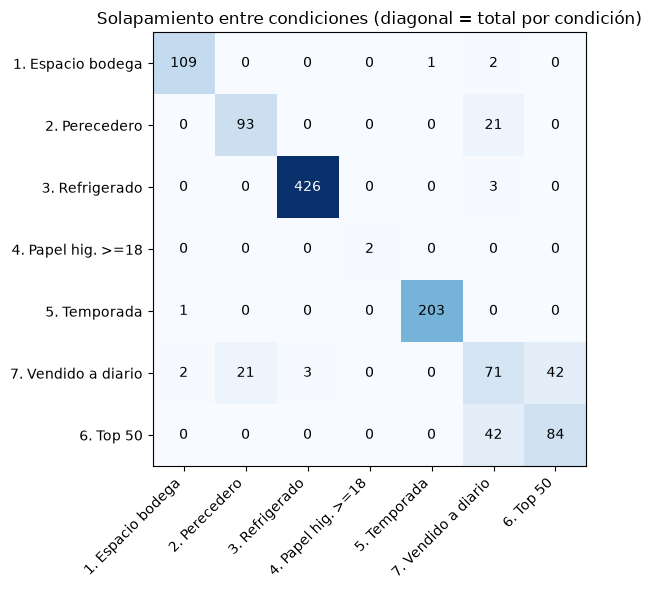

In [22]:
matriz_solape = dim_producto[todas_condiciones_prod].astype(int).T.dot(dim_producto[todas_condiciones_prod].astype(int)).values
etiquetas_matriz = etiquetas_condiciones + ['6. Top 50']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz_solape, cmap='Blues')
ax.set_xticks(range(len(etiquetas_matriz))); ax.set_xticklabels(etiquetas_matriz, rotation=45, ha='right')
ax.set_yticks(range(len(etiquetas_matriz))); ax.set_yticklabels(etiquetas_matriz)
for i in range(len(etiquetas_matriz)):
    for j in range(len(etiquetas_matriz)):
        ax.text(j, i, matriz_solape[i, j], ha='center', va='center',
                color='white' if matriz_solape[i, j] > matriz_solape.max() / 2 else 'black')
ax.set_title('Solapamiento entre condiciones (diagonal = total por condición)')
plt.tight_layout()
plt.show()


In [23]:
# La matriz de arriba muestra PROPORCIÓN de solapamiento, que no es lo mismo
# que APORTE absoluto -- "papel higiénico casi no solapa con nada" es
# cierto, pero dice poco sobre cuántos SKU exclusivos trae en términos
# absolutos. Se cuenta directamente: productos que SOLO cumplen esa
# condición y ninguna otra.
solo_esta = {
    c: int((dim_producto[todas_condiciones_prod].sum(axis=1).eq(1) & dim_producto[c]).sum())
    for c in todas_condiciones_prod
}
solo_esta_s = pd.Series(solo_esta, index=todas_condiciones_prod)
solo_esta_s.index = etiquetas_matriz
print(solo_esta_s.sort_values(ascending=False))


3. Refrigerado         423
5. Temporada           202
1. Espacio bodega      106
2. Perecedero           72
6. Top 50               42
7. Vendido a diario      3
4. Papel hig. >=18       2
dtype: int64


La condición con menor proporción de solapamiento no es necesariamente
la que más SKU exclusivos aporta en términos absolutos -- proporción de
solapamiento (qué tan "propia" es la condición) y aporte absoluto (cuántos
SKU trae) son dos preguntas distintas, y la tabla de arriba responde la
segunda directamente en vez de inferirla de la matriz de solapamiento.

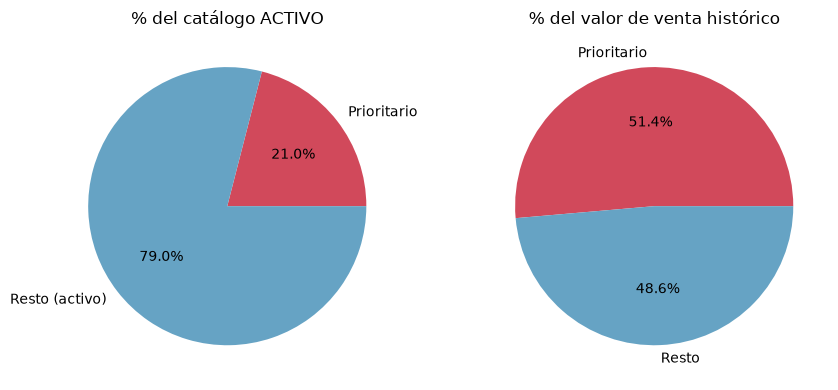

919 productos prioritarios de 4414 catálogo total (20.8%) | 21.0% del catálogo activo
representan 51.4% del valor total de venta histórico


In [24]:
prioritarios = set(dim_producto.loc[dim_producto['es_prioritario'], 'codigo_item'])
valor_prioritario = valor_por_producto.reindex(prioritarios).sum()
pct_catalogo = len(prioritarios) / len(dim_producto)
pct_catalogo_activo = len(prioritarios) / n_catalogo_activo
pct_valor = valor_prioritario / valor_total

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].pie([len(prioritarios), n_catalogo_activo - len(prioritarios)],
            labels=['Prioritario', 'Resto (activo)'], autopct='%1.1f%%',
            colors=[COLOR_PRIORITARIO, COLOR_NO_PRIORITARIO])
axes[0].set_title('% del catálogo ACTIVO')
axes[1].pie([valor_prioritario, valor_total - valor_prioritario],
            labels=['Prioritario', 'Resto'], autopct='%1.1f%%',
            colors=[COLOR_PRIORITARIO, COLOR_NO_PRIORITARIO])
axes[1].set_title('% del valor de venta histórico')
plt.tight_layout()
plt.show()

print(f'{len(prioritarios)} productos prioritarios de {len(dim_producto)} catálogo total ({pct_catalogo:.1%})',
      f'| {pct_catalogo_activo:.1%} del catálogo activo')
print(f'representan {pct_valor:.1%} del valor total de venta histórico')


## 7. Contrafactual — ¿qué captura un ABC puro por valor?

Se compara la regla de negocio contra tomar el mismo tamaño de catálogo
(el N-avo superior por valor, sin ninguna de las 7 condiciones).

Tomando el top 919 productos por valor (mismo tamaño que el conjunto de negocio):
  captura 79.4% del valor total (vs. 51.4% de la regla de negocio)
  349 productos en común (38.0% de solapamiento)


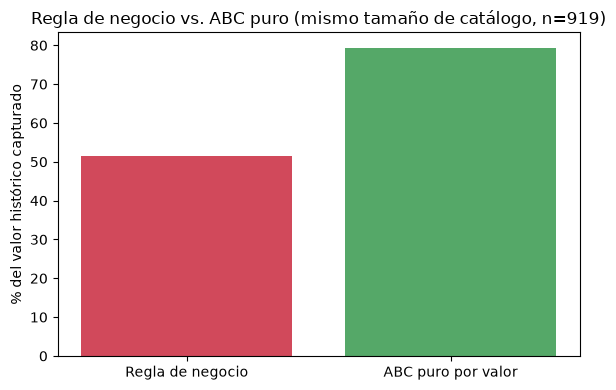

In [25]:
n_equivalente = len(prioritarios)
top_valor = valor_por_producto.sort_values(ascending=False).head(n_equivalente)
valor_abc = top_valor.sum()
codigos_abc = set(top_valor.index)

interseccion = codigos_abc & prioritarios
print(f'Tomando el top {n_equivalente} productos por valor (mismo tamaño que el conjunto de negocio):')
print(f'  captura {valor_abc/valor_total:.1%} del valor total (vs. {pct_valor:.1%} de la regla de negocio)')
print(f'  {len(interseccion)} productos en común ({len(interseccion)/n_equivalente:.1%} de solapamiento)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Regla de negocio', 'ABC puro por valor'], [pct_valor * 100, valor_abc / valor_total * 100],
       color=[COLOR_PRIORITARIO, '#55a868'])
ax.set_ylabel('% del valor histórico capturado')
ax.set_title(f'Regla de negocio vs. ABC puro (mismo tamaño de catálogo, n={n_equivalente})')
plt.tight_layout()
plt.show()


El ABC por valor sube el porcentaje de ingresos capturado -- es
esperable, porque optimiza exactamente para eso. La regla de negocio no
busca maximizar valor: busca minimizar riesgo operativo (perecederos,
espacio en bodega, temporada), criterios que el ABC no ve. El solapamiento
de arriba muestra cuánto de "lo importante por valor" ya queda cubierto
igual por la regla, sin haberlo buscado explícitamente.

In [26]:
# El número complementario: cuánto valor de alto rango queda FUERA de la
# regla, no solo qué porcentaje de solapamiento hay.
codigos_abc_no_cubierto = codigos_abc - prioritarios
valor_abc_no_cubierto = valor_por_producto.reindex(codigos_abc_no_cubierto).sum() / valor_total
print(f'{len(codigos_abc_no_cubierto)} de los {n_equivalente} productos de mayor valor quedan FUERA de la regla de negocio',
      f'({len(codigos_abc_no_cubierto)/n_equivalente:.1%} del conjunto ABC).')
print(f'Eso representa el {valor_abc_no_cubierto:.1%} del valor histórico total.')


570 de los 919 productos de mayor valor quedan FUERA de la regla de negocio (62.0% del conjunto ABC).
Eso representa el 32.4% del valor histórico total.


Ese porcentaje es el valor que la regla **acepta** no cubrir a cambio
de cubrir riesgo operativo en su lugar -- el argumento de que "la regla no
busca maximizar ingresos" se sostiene mejor citando esta cifra concreta
que dejándolo como una afirmación sin número detrás.

## 8. Verificación y salidas para la cadena

In [27]:
assert dim_producto['es_prioritario'].dtype == bool
assert set(prioridad_par.loc[prioridad_par['es_prioritario'], 'codigo_item']) <= prioritarios, \
    'un par prioritario debe corresponder a un producto marcado prioritario en la vista agregada'
assert (dim_producto.groupby('codigo_item').size() == 1).all(), 'dim_producto_priorizado con códigos duplicados'
print('Invariantes de consolidación verificadas OK.')

dim_producto.to_parquet(f'{DW}/dim_producto_priorizado.parquet', index=False)
print('guardado:', f'{DW}/dim_producto_priorizado.parquet')


Invariantes de consolidación verificadas OK.
guardado: /home/ddelgadillo@redcorporativa.corpoica.org.co/otros/etl/InventaIO/data/processed_real/dim_producto_priorizado.parquet


In [28]:
huella = {
    'notebook': '02_regla_priorizacion',
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'entradas': registrar_huella([
        'dim_producto.csv', 'fact_ventas.csv', 'dim_sucursal.csv',
        'panel_diario.parquet', 'panel_diario_negocio.parquet',
        'ventana_activa.parquet', 'ventana_activa_negocio.parquet',
    ]),
    'salidas': registrar_huella(['priorizacion_producto_sucursal.parquet', 'dim_producto_priorizado.parquet']),
}
with open(f'{DW}/huella_02.json', 'w') as f:
    json.dump(huella, f, indent=2, ensure_ascii=False)
print('guardado: huella_02.json')
huella


guardado: huella_02.json


{'notebook': '02_regla_priorizacion',
 'fecha_generacion': '2026-09-18T09:39:51.059869',
 'entradas': {'dim_producto.csv': '46628503cc10',
  'fact_ventas.csv': '904aaeef7217',
  'dim_sucursal.csv': '71c7ffefc2e1',
  'panel_diario.parquet': 'df1ab3417e0c',
  'panel_diario_negocio.parquet': '147eef51852c',
  'ventana_activa.parquet': '96edc5e2d678',
  'ventana_activa_negocio.parquet': '211fabb050f0'},
 'salidas': {'priorizacion_producto_sucursal.parquet': '0750d5792cc8',
  'dim_producto_priorizado.parquet': '68e0a2fc304c'}}